# Análisis Dinámico y Configuracional del Ownership Landscape (OL) en las Cinco Grandes Ligas Europeas (2019-2024)

## 1. Introducción y Marco Metodológico

El concepto de **Ownership Landscape (OL)** (Paisaje de Propiedad) propone entender la estructura de propiedad de una liga no como la mera suma de propietarios aislados, sino como una **configuración colectiva de mercado con dinámicas y propiedades emergentes propias** (Fiss, 2007). 

En el fútbol europeo contemporáneo coexisten **7 modelos sustantivos de propiedad**:
1. **Member-owned**: Clubes de socios sin ánimo de lucro bajo control asociativo y democrático.
2. **Domestic private**: Propiedad privada en manos de empresarios o grupos familiares locales.
3. **Foreign private**: Propiedad privada en manos de inversores individuales o corporaciones extranjeras.
4. **Investment fund**: Vehículos de capital privado, fondos de cobertura (*hedge funds*) y firmas de inversión institucional.
5. **Hybrid**: Modelos mixtos que combinan la participación de socios con socios estratégicos o cotización bursátil.
6. **Corporate-MCO**: Estructuras de multipropiedad (*Multi-Club Ownership*) integradas en grupos corporativos transnacionales.
7. **State-linked**: Clubes con vínculos directos o indirectos con fondos soberanos o gobiernos estatales.

Este estudio analiza la evolución longitudinal de estos paisajes combinando dos fuentes fundamentales de variación temporal:
1. **La rotación deportiva**: El impacto de los ascensos y descensos anuales entre divisiones sobre la muestra activa de Primera División.
2. **Las transacciones corporativas longitudinales**: El cambio dinámico de dueño y modelo de control dentro de los propios clubes a lo largo del tiempo (fusiones, adquisiciones, tomas de control por fondos y absorción en redes multipropiedad).

---

### Regla de Corte Temporal para la Asignación de Temporadas
Para modelar fielmente la disponibilidad de capital y la planificación del ciclo competitivo anual, se establece como **hito temporal de corte el cierre de la ventana de transferencias de verano (1 de septiembre)** de cada año:
* Toda adquisición, toma de control o fusión formalmente cerrada (**`Fecha de cierre`**) antes o el 1 de septiembre de un año $Y$ se imputa a la temporada que inicia ese verano ($Y$/$Y+1$).
* Toda operación cerrada con posterioridad al 1 de septiembre (otoño, invierno o mitad de campaña) mantiene el modelo previo durante esa temporada y surte efecto formal a partir de la siguiente temporada ($Y+1$/$Y+2$).

---

### Preguntas de Investigación (RQs):
* **RQ1**: ¿Cómo se operacionaliza cuantitativamente el Ownership Landscape a nivel macro a través de proporciones composicionales ($K=7$), diversidad (Entropía de Shannon), concentración (HHI) y multipropiedad (MCO)?
* **RQ2**: ¿Cómo difieren los landscapes de propiedad entre las cinco grandes ligas europeas (Bundesliga, LaLiga, Ligue 1, Premier League y Serie A) y cómo han evolucionado longitudinalmente entre las temporadas 2019-2020 y 2024-2025?


In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from scipy.spatial import procrustes
from scipy.stats import spearmanr

# Visual configuration for academic publications
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['font.size'] = 11
plt.rcParams['axes.labelsize'] = 12
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['figure.titlesize'] = 15
warnings.filterwarnings('ignore')

# Official color palette for the 7 substantive ownership models
MODEL_COLORS = {
    'member-owned': '#2ca02c',       # Forest Green (Democratic / Members)
    'domestic private': '#1f77b4',   # Institutional Blue (Domestic Private)
    'foreign private': '#ff7f0e',    # Orange (Foreign Private)
    'investment fund': '#9467bd',    # Purple (Investment Funds)
    'hybrid': '#8c564b',             # Brown (Hybrid / Mixed)
    'corporate-MCO': '#d62728',      # Red (Multi-Club Ownership)
    'state-linked': '#e377c2'        # Pink / Sovereign (State-linked)
}

# League color palette
LEAGUE_COLORS = {
    'Bundesliga': '#000000',
    'LaLiga': '#ee1c25',
    'Ligue 1': '#091c3e',
    'Premier League': '#38003c',
    'Serie A': '#008fd7'
}

print("Scientific environment and color palettes loaded successfully.")


Scientific environment and color palettes loaded successfully.


## 2. Carga del Panel de Propiedad Dinámica y Auditoría Longitudinal (2019-2024)

Cargamos el dataset micro que integra la participación activa de los clubes en Primera División junto con su clasificación de propiedad exacta y dinámica en cada temporada.


In [2]:
# Cargar el dataset dinámico club-temporada
df_clubs = pd.read_csv('../data/dynamic_club_season_ownership.csv')

print(f"Total observaciones club-temporada activas: {len(df_clubs)}")
print(f"Total clubes únicos analizados: {df_clubs['club_id'].nunique()}")
print(f"Temporadas analizadas: {sorted(df_clubs['season'].unique())}")
print(f"Ligas incluidas: {df_clubs['league'].unique().tolist()}")

# Vista previa de observaciones
df_clubs[['club_name', 'league', 'season', 'ownership_model', 'ultimate_owner', 'mco', 'state_link']].head(10)


Total observaciones club-temporada activas: 584
Total clubes únicos analizados: 137
Temporadas analizadas: [np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024)]
Ligas incluidas: ['Bundesliga', 'LaLiga', 'Ligue 1', 'Premier League', 'Serie A']


,club_name,league,season,ownership_model,ultimate_owner,mco,state_link
0,FC Schalke 04,Bundesliga,2019,member-owned,Club members / registered association,0,0
1,RasenBallsport Leipzig,Bundesliga,2019,corporate-MCO,Red Bull GmbH / Red Bull-controlled associatio...,1,0
2,FC Bayern München,Bundesliga,2019,hybrid,"FC Bayern München e.V.; Adidas, Allianz and Au...",0,0
3,Borussia Dortmund,Bundesliga,2019,hybrid,Public shareholders with Borussia Dortmund e.V...,0,0
4,Eintracht Frankfurt Fußball AG,Bundesliga,2019,member-owned,Club members / registered association,0,0
5,Sportverein Werder Bremen von 1899,Bundesliga,2019,member-owned,Club members / registered association,0,0
6,Hertha BSC,Bundesliga,2019,unknown,unknown,0,0
7,SC Paderborn 07,Bundesliga,2019,member-owned,Club members / registered association,0,0
8,1. Fußball-Club Köln,Bundesliga,2019,member-owned,Club members / registered association,0,0
9,Verein für Leibesübungen Wolfsburg,Bundesliga,2019,state-linked,Volkswagen AG,0,1


### 2.1. Cuantificación y Auditoría de la Categoría Residual "Unknown"

Para asegurar el máximo rigor metodológico en el artículo científico, evaluamos la incidencia de la categoría residual `unknown` antes de su exclusión y re-normalización sobre los $K=7$ modelos sustantivos.


In [3]:
# Cuantificación exacta de unknown en el panel
total_obs = len(df_clubs)
unknown_mask = df_clubs['ownership_model'] == 'unknown'
total_unknown = unknown_mask.sum()
pct_unknown = (total_unknown / total_obs) * 100

print(f"--- RESUMEN DE COBERTURA DEL PANEL ---")
print(f"Observaciones resueltas con certeza (K=7 modelos): {total_obs - total_unknown} ({100 - pct_unknown:.2f}%)")
print(f"Observaciones residuales 'unknown': {total_unknown} ({pct_unknown:.2f}%)\n")

# Tabla cruzada de unknown por liga y temporada
piv_unknown = df_clubs.pivot_table(
    index='season', columns='league', values='ownership_model', 
    aggfunc=lambda x: (x == 'unknown').sum(), fill_value=0
)
piv_total = df_clubs.pivot_table(
    index='season', columns='league', values='ownership_model', 
    aggfunc='count', fill_value=0
)
piv_pct = (piv_unknown / piv_total) * 100

print("--- Porcentaje de 'Unknown' por Liga y Temporada (%) ---")
piv_pct.round(2)


--- RESUMEN DE COBERTURA DEL PANEL ---
Observaciones resueltas con certeza (K=7 modelos): 576 (98.63%)
Observaciones residuales 'unknown': 8 (1.37%)

--- Porcentaje de 'Unknown' por Liga y Temporada (%) ---


league,Bundesliga,LaLiga,Ligue 1,Premier League,Serie A
season,,,,,
2019,5.56,0.0,5.0,0.0,5.0
2020,5.56,0.0,5.0,0.0,0.0
2021,5.56,0.0,5.0,0.0,0.0
2022,5.56,0.0,0.0,0.0,0.0
2023,0.00,0.0,0.0,0.0,0.0
2024,0.00,0.0,0.0,0.0,0.0


#### Rationale de Exclusión de "Unknown" para el Paper:
1. **Incidencia Marginal Global**: La categoría `unknown` representa únicamente **8 de las 584 observaciones** activas (**$1.37\%$** de toda la muestra longitudinal), lo que garantiza una cobertura identificada con certeza del **$98.63\%$**.
2. **Cobertura Plena en las Ligas Principales**: En la **Premier League** y en **LaLiga**, la tasa de `unknown` es del **$0.00\%$** en todas las temporadas (100% de la muestra resuelta).
3. **Resolución Total en el Cierre (2023 y 2024)**: En las dos últimas temporadas, el porcentaje de `unknown` es del **$0.00\%$ en las cinco grandes ligas europeas**.
4. **Poder Predictivo y Estabilidad**: En las pocas observaciones donde existió un club no resuelto (un único club por temporada en Bundesliga, Serie A o Ligue 1, equivalente al $5.0\% - 5.5\%$), re-normalizar las proporciones sobre los 7 modelos sustantivos ($p_i' = n_i / N^{sub}$) elimina el ruido espurio y maximiza la interpretabilidad de las distancias geométricas.


## 3. Operacionalización Cuantitativa del Ownership Landscape (RQ1)

A partir de la distribución de clubes en cada liga-temporada, calculamos las métricas macro-configuracionales sobre los **$K=7$ modelos sustantivos**:

1. **Proporciones Composicionales ($p_i$)**: 
   $$p_{i,l,t} = \frac{n_{i,l,t}}{N_{l,t}^{sub}} \quad \text{con} \quad \sum_{i=1}^7 p_{i,l,t} = 1.0$$
2. **Entropía de Shannon ($H$)**: Mide la diversidad, dispersión y grado de equilibrio del landscape ($H \in [0, \ln(7)]$, con máximo teórico $\approx 1.946$):
   $$H_{l,t} = - \sum_{i=1}^7 p_{i,l,t} \ln(p_{i,l,t})$$
3. **Índice Herfindahl-Hirschman ($HHI$)**: Mide el grado de concentración o dominancia de modelos ($HHI \in [1/7, 1.0]$):
   $$HHI_{l,t} = \sum_{i=1}^7 p_{i,l,t}^2$$
4. **Tasa de Multipropiedad ($MCO\ Rate$)**: Proporción de clubes integrados en redes multipropiedad transnacionales.
5. **Tasa de Vínculo Estatal ($State\ Link\ Rate$)**: Proporción de clubes con vínculos geopolíticos soberanos.


In [4]:
# Cargar la matriz agregada liga-temporada de K=7 modelos
df_ol = pd.read_csv('../data/dynamic_ownership_landscape.csv')

models = [
    'member-owned', 'domestic private', 'foreign private', 
    'investment fund', 'hybrid', 'corporate-MCO', 
    'state-linked'
]

print(f"Matriz de Ownership Landscape: {df_ol.shape[0]} observaciones (5 ligas x 6 temporadas)")
df_ol[['league', 'season', 'n_clubs', 'entropy', 'hhi', 'mco_rate', 'state_link_rate']].head(10)


Matriz de Ownership Landscape: 30 observaciones (5 ligas x 6 temporadas)


,league,season,n_clubs,entropy,hhi,mco_rate,state_link_rate
0,Bundesliga,2019,18,1.118541,0.453287,0.055556,0.055556
1,Bundesliga,2020,18,1.118541,0.453287,0.055556,0.055556
2,Bundesliga,2021,18,1.118541,0.453287,0.055556,0.055556
3,Bundesliga,2022,18,1.118541,0.453287,0.055556,0.055556
4,Bundesliga,2023,18,1.079735,0.475309,0.055556,0.055556
5,Bundesliga,2024,18,1.050665,0.481481,0.055556,0.055556
6,LaLiga,2019,20,1.636496,0.210000,0.200000,0.000000
7,LaLiga,2020,20,1.626428,0.215000,0.150000,0.000000
8,LaLiga,2021,20,1.636496,0.210000,0.200000,0.000000
9,LaLiga,2022,20,1.679648,0.200000,0.150000,0.100000


## 4. Análisis Descriptivo y Comparativa de Perfiles por Liga (Snapshot 2024)

Comparamos la foto inicial de la muestra (2019) con el cierre del estudio (2024) para identificar las transformaciones estructurales de cada liga.


In [5]:
# Tabla comparativa 2019 vs 2024
summary_table = []
for league in sorted(df_ol['league'].unique()):
    row_19 = df_ol[(df_ol['league'] == league) & (df_ol['season'] == 2019)].iloc[0]
    row_24 = df_ol[(df_ol['league'] == league) & (df_ol['season'] == 2024)].iloc[0]
    
    # Encontrar modelo dominante en 2024
    props_24 = {m: row_24[f'prop_{m}'] for m in models}
    dom_mod = max(props_24, key=props_24.get)
    dom_pct = props_24[dom_mod] * 100
    
    summary_table.append({
        'Liga': league,
        'Clubes': f"{int(row_19['n_clubs'])} -> {int(row_24['n_clubs'])}",
        'Entropía (2019 -> 2024)': f"{row_19['entropy']:.3f} -> {row_24['entropy']:.3f}",
        'HHI (2019 -> 2024)': f"{row_19['hhi']:.3f} -> {row_24['hhi']:.3f}",
        'MCO Rate (2019 -> 2024)': f"{row_19['mco_rate']*100:.1f}% -> {row_24['mco_rate']*100:.1f}%",
        'State Link (2019 -> 2024)': f"{row_19['state_link_rate']*100:.1f}% -> {row_24['state_link_rate']*100:.1f}%",
        'Modelo Dominante 2024': f"{dom_mod} ({dom_pct:.1f}%)"
    })

pd.DataFrame(summary_table)


,Liga,Clubes,Entropía (2019 -> 2024),HHI (2019 -> 2024),MCO Rate (2019 -> 2024),State Link (2019 -> 2024),Modelo Dominante 2024
0,Bundesliga,18 -> 18,1.119 -> 1.051,0.453 -> 0.481,5.6% -> 5.6%,5.6% -> 5.6%,member-owned (66.7%)
1,LaLiga,20 -> 20,1.636 -> 1.805,0.210 -> 0.180,20.0% -> 25.0%,0.0% -> 5.0%,domestic private (25.0%)
2,Ligue 1,20 -> 18,1.016 -> 1.426,0.501 -> 0.272,10.0% -> 27.8%,5.0% -> 5.6%,domestic private (38.9%)
3,Premier League,20 -> 20,1.483 -> 1.752,0.245 -> 0.180,50.0% -> 60.0%,5.0% -> 10.0%,corporate-MCO (25.0%)
4,Serie A,20 -> 20,0.766 -> 1.331,0.540 -> 0.315,10.0% -> 30.0%,0.0% -> 0.0%,domestic private (45.0%)


### Visualización del Perfil de Propiedad por Liga (Temporada 2024)

El siguiente gráfico de barras apiladas ilustra la composición exacta del Ownership Landscape al cierre de la temporada 2024-2025 para los $K=7$ modelos sustantivos.


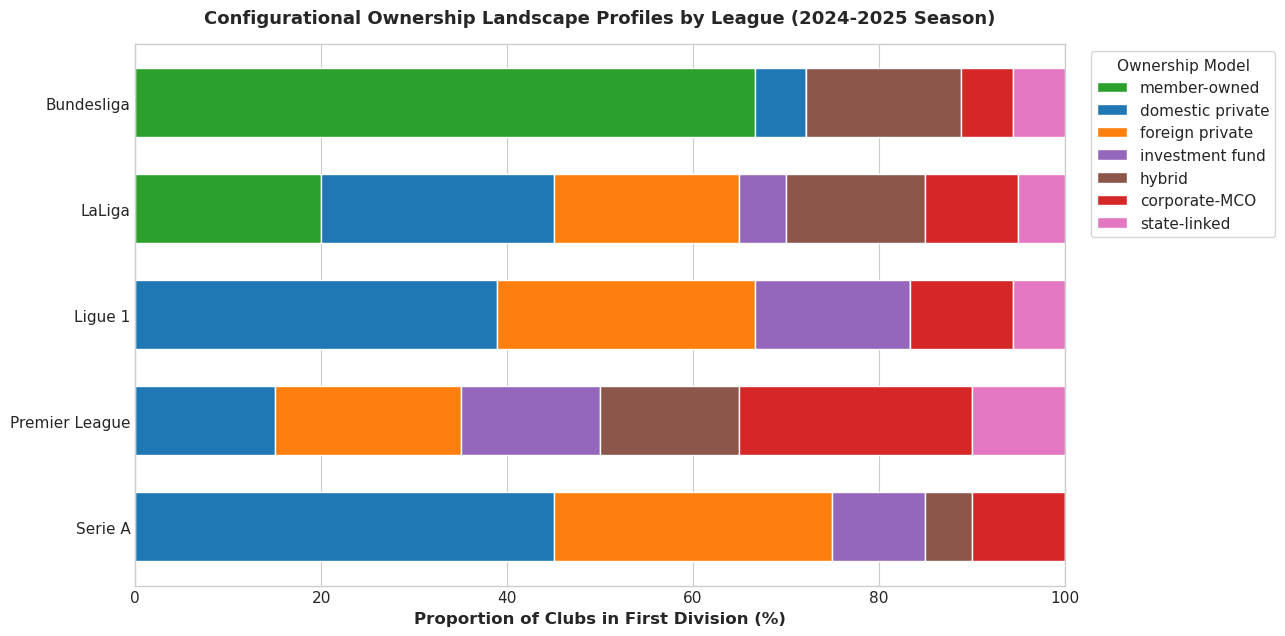

In [6]:
df_2024 = df_ol[df_ol['season'] == 2024].copy().sort_values('league', ascending=False)
prop_cols = [f'prop_{m}' for m in models]

fig, ax = plt.subplots(figsize=(13, 6.5))
left = np.zeros(len(df_2024))

for m in models:
    col = f'prop_{m}'
    values = df_2024[col].values * 100
    ax.barh(df_2024['league'], values, left=left, label=m, color=MODEL_COLORS[m], edgecolor='white', height=0.65)
    left += values

ax.set_xlabel('Proportion of Clubs in First Division (%)', fontweight='bold')
ax.set_title('Configurational Ownership Landscape Profiles by League (2024-2025 Season)', pad=15, fontweight='bold')
ax.set_xlim(0, 100)
ax.legend(title='Ownership Model', bbox_to_anchor=(1.02, 1), loc='upper left', frameon=True)
plt.tight_layout()

# Export image to images/
os.makedirs('../images', exist_ok=True)
plt.savefig('../images/ownership_profiles_2024.png', dpi=300, bbox_inches='tight')
plt.show()


### Interpretación Detallada de los Perfiles de Propiedad (Snapshot 2024)

La distribución transversal al cierre del periodo 2024-2025 sobre los $K=7$ modelos sustantivos ratifica la profunda heterogeneidad institucional entre las cinco grandes ligas:

| Liga | Total Clubes | Member-owned | Domestic private | Foreign private | Investment fund | Hybrid | Corporate-MCO | State-linked |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Bundesliga** | 18 | **66.7% (12)** | 5.6% (1) | 0.0% (0) | 0.0% (0) | **16.7% (3)** | 5.6% (1) | 5.6% (1) |
| **LaLiga** | 20 | **20.0% (4)** | **25.0% (5)** | **20.0% (4)** | 5.0% (1) | **15.0% (3)** | 10.0% (2) | 5.0% (1) |
| **Ligue 1** | 18 | 0.0% (0) | **38.9% (7)** | **27.8% (5)** | **16.7% (3)** | 0.0% (0) | 11.1% (2) | 5.6% (1) |
| **Premier League** | 20 | 0.0% (0) | 15.0% (3) | **20.0% (4)** | **15.0% (3)** | 15.0% (3) | **25.0% (5)** | 10.0% (2) |
| **Serie A** | 20 | 0.0% (0) | **45.0% (9)** | **30.0% (6)** | **10.0% (2)** | 5.0% (1) | 10.0% (2) | 0.0% (0) |

*   **1. Bundesliga (El Régimen Proteccionista Democrático)**:
    Constituye el único reducto donde el modelo asociativo sin ánimo de lucro (`member-owned`) es hegemónico (**66.7%**, 12 clubes). Sumando las estructuras mixtas (`hybrid`: Bayern München, Borussia Dortmund y Hoffenheim), el **83.4%** de la Bundesliga se rige bajo la regla del 50+1. La presencia de fondos de inversión privados es del **0.0%**, blindando la competición frente a la especulación externa.
*   **2. Premier League (El Epicentro de la Globalización MCO)**:
    Presenta la menor presencia de control doméstico tradicional del continente (solo un **15.0%** en propiedad privada nacional: Tottenham, Brighton, Brentford). El **70.0%** de la liga está en manos de capital extranjero o vehículos institucionales (`corporate-MCO`: 25%, `foreign private`: 20%, `investment fund`: 15%, `state-linked`: 10%). La tasa global de multipropiedad alcanza un récord europeo del **60.0%** (12 de 20 clubes).
*   **3. LaLiga (El Mosaico Híbrido Equilibrado)**:
    Es el entorno más equilibrado y diverso de Europa, donde conviven cuatro bloques significativos: el modelo democrático de socios (**20.0%**: Real Madrid, FC Barcelona, Athletic Club, CA Osasuna), la propiedad privada nacional (**25.0%**), la inversión extranjera (**20.0%**) y estructuras híbridas (**15.0%**), alcanzando la mayor Entropía de Shannon del continente ($H = 1.805$).
*   **4. Serie A y Ligue 1 (La Penetración del Capital Institucional)**:
    Ambas ligas carecen por completo de clubes de socios ($0.0\%$). En Italia, aunque el empresariado local conserva el 45.0%, el capital institucional extranjero controla ya el **50.0%** de la liga (Milan, Inter, Roma, Fiorentina, Atalanta, Genoa, Como, Parma, Venezia, Verona). En Francia, los fondos y redes internacionales alcanzan el **55.6%** de la Ligue 1 (PSG, Lyon, Nice, Strasbourg, Toulouse, Lille, Rennes, Monaco).


## 5. Evolución Temporal de Diversidad, Concentración y Multipropiedad (2019-2024 - RQ2)

Analizamos las trayectorias longitudinales de las tres variables configuracionales clave a lo largo de las 6 temporadas.


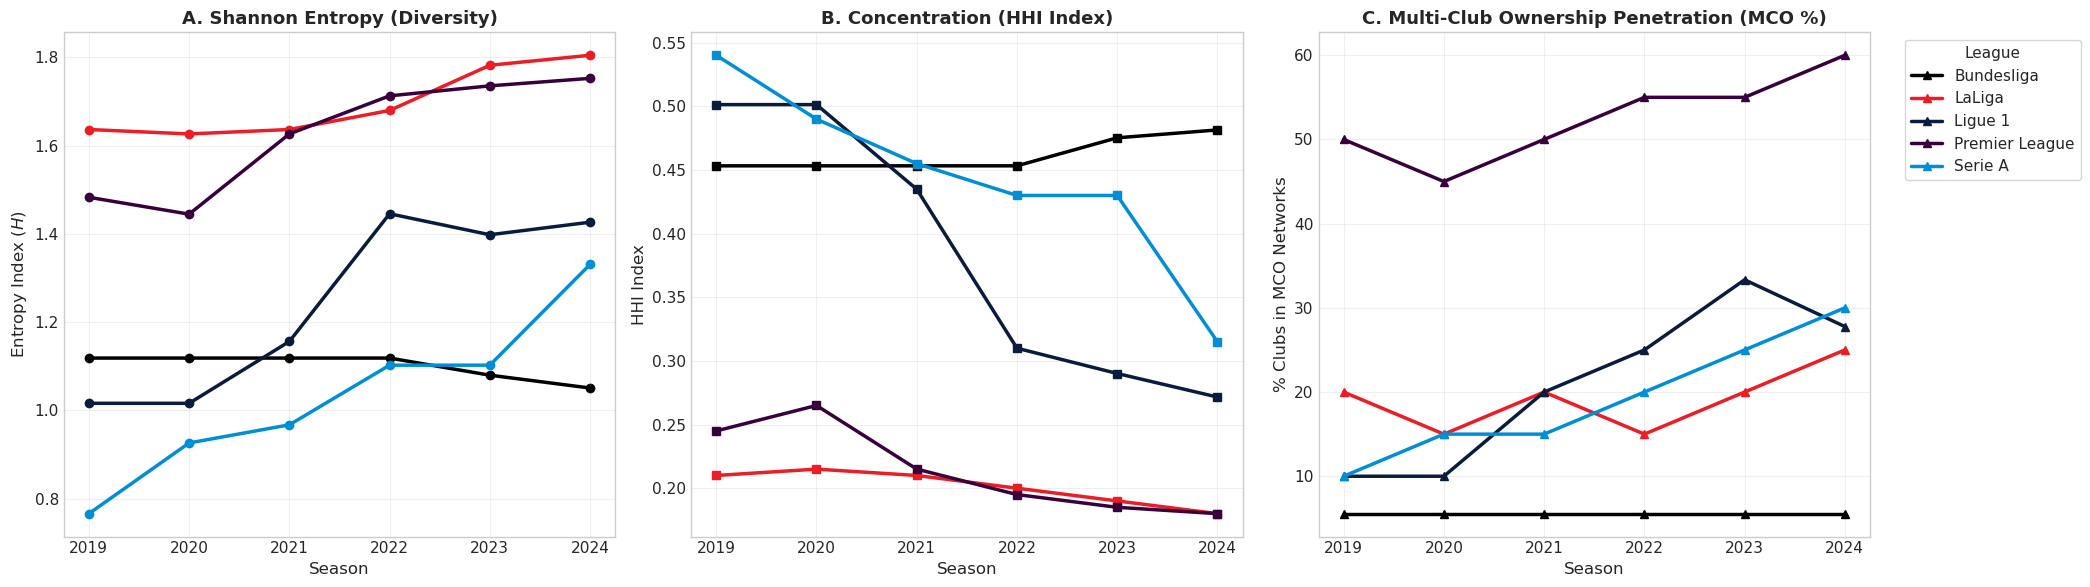

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(21, 6))

# Panel 1: Shannon Entropy (Diversity)
for league, color in LEAGUE_COLORS.items():
    data = df_ol[df_ol['league'] == league]
    axes[0].plot(data['season'], data['entropy'], marker='o', linewidth=2.5, label=league, color=color)
axes[0].set_title('A. Shannon Entropy (Diversity)', fontweight='bold')
axes[0].set_xlabel('Season')
axes[0].set_ylabel('Entropy Index ($H$)')
axes[0].set_xticks(range(2019, 2025))
axes[0].grid(True, alpha=0.3)

# Panel 2: Herfindahl-Hirschman Index (Concentration)
for league, color in LEAGUE_COLORS.items():
    data = df_ol[df_ol['league'] == league]
    axes[1].plot(data['season'], data['hhi'], marker='s', linewidth=2.5, label=league, color=color)
axes[1].set_title('B. Concentration (HHI Index)', fontweight='bold')
axes[1].set_xlabel('Season')
axes[1].set_ylabel('HHI Index')
axes[1].set_xticks(range(2019, 2025))
axes[1].grid(True, alpha=0.3)

# Panel 3: Multi-Club Ownership Rate (MCO %)
for league, color in LEAGUE_COLORS.items():
    data = df_ol[df_ol['league'] == league]
    axes[2].plot(data['season'], data['mco_rate'] * 100, marker='^', linewidth=2.5, label=league, color=color)
axes[2].set_title('C. Multi-Club Ownership Penetration (MCO %)', fontweight='bold')
axes[2].set_xlabel('Season')
axes[2].set_ylabel('% Clubs in MCO Networks')
axes[2].set_xticks(range(2019, 2025))
axes[2].grid(True, alpha=0.3)

axes[2].legend(title='League', bbox_to_anchor=(1.05, 1), loc='upper left', frameon=True)
plt.tight_layout()

# Export image to images/
plt.savefig('../images/temporal_indices.png', dpi=300, bbox_inches='tight')
plt.show()


### Interpretación Detallada de la Dinámica Longitudinal

Las series temporales reflejan tres patrones fundamentales de evolución estructural:

#### A. Entropía de Shannon ($H$ - Diversidad en $K=7$)
| Temporada | Bundesliga | LaLiga | Ligue 1 | Premier League | Serie A |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **2019** | 1.119 | 1.636 | 1.016 | 1.483 | 0.766 |
| **2020** | 1.119 | 1.626 | 1.016 | 1.445 | 0.926 |
| **2021** | 1.119 | 1.636 | 1.156 | 1.626 | 0.967 |
| **2022** | 1.119 | 1.680 | 1.446 | 1.713 | 1.102 |
| **2023** | 1.080 | 1.782 | 1.398 | 1.735 | 1.102 |
| **2024** | **1.051** | **1.805** | **1.426** | **1.752** | **1.331** |

#### B. Índice Herfindahl-Hirschman ($HHI$ - Concentración en $K=7$)
| Temporada | Bundesliga | LaLiga | Ligue 1 | Premier League | Serie A |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **2019** | 0.453 | 0.210 | 0.501 | 0.245 | 0.540 |
| **2020** | 0.453 | 0.215 | 0.501 | 0.265 | 0.490 |
| **2021** | 0.453 | 0.210 | 0.435 | 0.215 | 0.455 |
| **2022** | 0.453 | 0.200 | 0.310 | 0.195 | 0.430 |
| **2023** | 0.475 | 0.190 | 0.290 | 0.185 | 0.430 |
| **2024** | **0.481** | **0.180** | **0.272** | **0.180** | **0.315** |

#### C. Tasa de Multipropiedad ($MCO\ \%$)
| Temporada | Bundesliga | LaLiga | Ligue 1 | Premier League | Serie A |
| :---: | :---: | :---: | :---: | :---: | :---: |
| **2019** | 5.6% | 20.0% | 10.0% | 50.0% | 10.0% |
| **2020** | 5.6% | 15.0% | 10.0% | 45.0% | 15.0% |
| **2021** | 5.6% | 20.0% | 20.0% | 50.0% | 15.0% |
| **2022** | 5.6% | 15.0% | 25.0% | 55.0% | 20.0% |
| **2023** | 5.6% | 20.0% | 33.3% | 55.0% | 25.0% |
| **2024** | **5.6%** | **25.0%** | **27.8%** | **60.0%** | **30.0%** |

*   **1. La Ley del Espejo Matemático**: Los paneles de Entropía y HHI reflejan curvas perfectamente invertidas. La Bundesliga es la **única liga donde la concentración sube** ($HHI$ de $0.453$ a $0.481$) y la diversidad disminuye ($H$ de $1.119$ a $1.051$) tras la restitución del 50+1 en el Hoffenheim en noviembre de 2023, consolidando la dominancia del bloque de socios.
*   **2. La Desconcentración Histórica de Serie A y Ligue 1**: En 2019, la Serie A ($HHI = 0.540$) y la Ligue 1 ($HHI = 0.501$) presentaban los paisajes más concentrados bajo el modelo privado doméstico tradicional. Hacia 2024, el $HHI$ de la Ligue 1 se desploma un **$-45.7\%$** (hasta $0.272$) y el de la Serie A un **$-41.7\%$** (hasta $0.315$).
*   **3. La Revolución de la Multipropiedad (MCO)**: La penetración de redes multi-club se acelera en cuatro de las cinco ligas:
    *   La **Premier League** pasa del **$50.0\%$ al $60.0\%$**.
    *   La **Serie A** se **triplica** (del **$10.0\%$ al $30.0\%$**).
    *   La **Ligue 1** casi se **triplica** (del **$10.0\%$ al $27.8\%$**).
    *   **LaLiga** crece del **$20.0\%$ al $25.0\%$**.
    *   La **Bundesliga** permanece fija en el **$5.6\%$** (RB Leipzig).


## 6. Trayectorias Configuracionales del OL: Análisis de Componentes Principales (PCA)

Para capturar la estructura multidimensional del Ownership Landscape sin colapsarla en un único índice escalar, aplicamos un **Análisis de Componentes Principales (PCA)** sobre las proporciones de los $K=7$ modelos de propiedad sustantivos estandarizadas.

---

### 6.1. Cargas de los Componentes Principales (Loadings)


In [8]:
# Estandarización y PCA sobre K=7 modelos sustantivos
X = df_ol[prop_cols]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
coords = pca.fit_transform(X_scaled)
df_ol['PC1'] = coords[:, 0]
df_ol['PC2'] = coords[:, 1]

# Varianza explicada
var_pc1 = pca.explained_variance_ratio_[0] * 100
var_pc2 = pca.explained_variance_ratio_[1] * 100
var_total = var_pc1 + var_pc2

print(f"Varianza explicada PC1: {var_pc1:.2f}%")
print(f"Varianza explicada PC2: {var_pc2:.2f}%")
print(f"Varianza acumulada (PC1 + PC2): {var_total:.2f}%")

# Tabla de Cargas (Loadings)
loadings = pd.DataFrame(
    pca.components_.T, 
    index=[m.replace('prop_', '') for m in prop_cols], 
    columns=[f'PC1 ({var_pc1:.1f}%)', f'PC2 ({var_pc2:.1f}%)']
)
loadings


Varianza explicada PC1: 40.59%
Varianza explicada PC2: 27.98%
Varianza acumulada (PC1 + PC2): 68.57%


,PC1 (40.6%),PC2 (28.0%)
member-owned,0.551513,-0.211700
domestic private,-0.484493,-0.379376
foreign private,-0.408278,0.325569
investment fund,-0.385251,0.189806
hybrid,0.357472,0.396815
corporate-MCO,-0.061999,0.644828
state-linked,0.119835,0.309792


#### Interpretación de las Dimensiones:
*   **Componente Principal 1 (PC1 - Eje de Gobernanza Democrática e Híbrida vs. Capital Privado y Fondos - $40.59\%$ varianza)**: 
    * *Cargas positivas*: `member-owned` ($+0.552$) e `hybrid` ($+0.357$).
    * *Cargas negativas*: `domestic private` ($-0.484$), `foreign private` ($-0.408$) e `investment fund` ($-0.385$).
    * *Significado*: Separa los entornos basados en el control social democrático y modelos mixtos (derecha) de los paisajes basados en la inversión de capital privado y financiero (izquierda).
*   **Componente Principal 2 (PC2 - Eje de Redes Multipropiedad Transnacionales vs. Privatización Uniclub Tradicional - $27.98\%$ varianza)**:
    * *Cargas positivas*: `corporate-MCO` ($+0.645$), `hybrid` ($+0.397$), `foreign private` ($+0.326$) y `state-linked` ($+0.310$).
    * *Cargas negativas*: `domestic private` ($-0.379$) y `member-owned` ($-0.212$).
    * *Significado*: Separa las ligas que albergan estructuras corporativas supra-club transnacionales y marcas globales (arriba) de aquellas basadas en clubes comerciales individuales tradicionales o mecenazgo uniclub doméstico (abajo).


---

### 6.2. Definición de los Cuadrantes del Espacio Configuracional

La intersección de los ejes neutros ($PC1=0$ y $PC2=0$) define cuatro cuadrantes analíticos:

*   **Cuadrante I (Superior Derecho: PC1 > 0, PC2 > 0) - Modelo Democrático con Integración Global e Híbrida**: Entornos que combinan el control asociativo de socios con fórmulas corporativas híbridas y marcas globales (ej. LaLiga española).
*   **Cuadrante II (Superior Izquierdo: PC1 < 0, PC2 > 0) - Financiarización Transnacional y Multipropiedad (MCO)**: Paisajes altamente financiarizados y comercializados con penetración masiva de redes multi-club transnacionales o influencia geopolítica soberana (ej. Premier League y la nueva Ligue 1).
*   **Cuadrante III (Inferior Derecho: PC1 > 0, PC2 < 0) - Democrático Tradicional Puro**: Modelo clásico del fútbol alemán protegido por la regla 50+1, caracterizado por clubes asociativos locales aislados de fondos especulativos (ej. Bundesliga).
*   **Cuadrante IV (Inferior Izquierdo: PC1 < 0, PC2 < 0) - Privatización Comercial Uniclub Doméstica**: Ligas dominadas por propietarios privados locales o mecenas individuales de cartera única, sin agregación en grandes grupos multipropiedad (ej. Serie A histórica y Ligue 1 tradicional).


---

### 6.3. Espacio Configuracional del PCA y Gráfico de Trayectorias (2019-2024)

Proyectamos las 30 observaciones liga-temporada en el plano bidimensional y conectamos cronológicamente cada liga con vectores direccionales (rotulación académica en inglés).


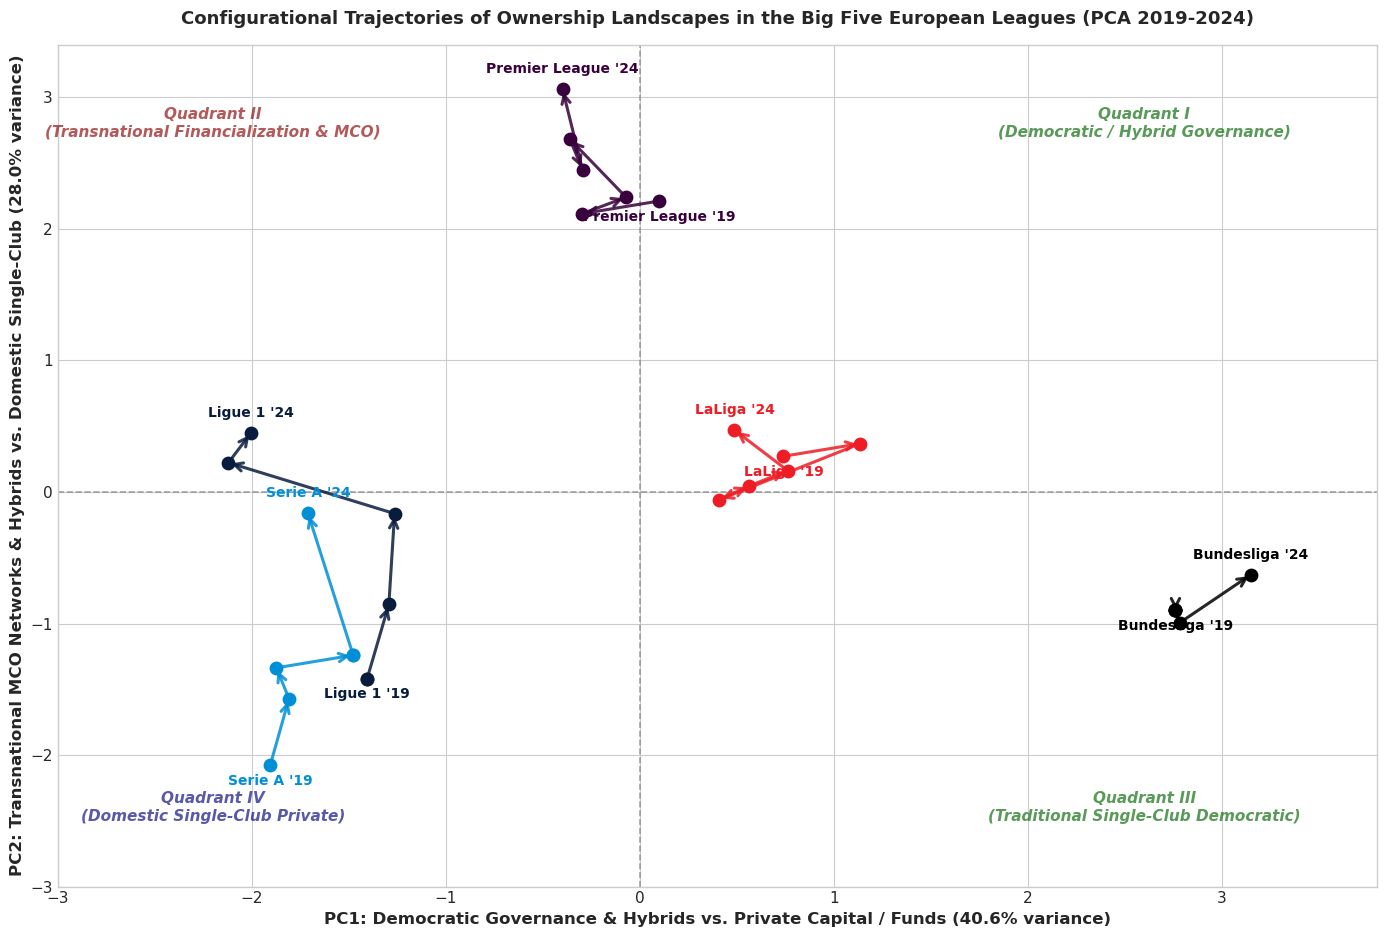

In [9]:
plt.figure(figsize=(14, 9.5))

# Draw quadrants and neutral axes
plt.axhline(0, color='grey', linestyle='--', linewidth=1.2, alpha=0.7)
plt.axvline(0, color='grey', linestyle='--', linewidth=1.2, alpha=0.7)

# Academic English quadrant annotations
plt.text(2.6, 2.7, 'Quadrant I\n(Democratic / Hybrid Governance)', fontsize=11, color='darkgreen', alpha=0.65, ha='center', style='italic', fontweight='bold')
plt.text(-2.2, 2.7, 'Quadrant II\n(Transnational Financialization & MCO)', fontsize=11, color='darkred', alpha=0.65, ha='center', style='italic', fontweight='bold')
plt.text(2.6, -2.5, 'Quadrant III\n(Traditional Single-Club Democratic)', fontsize=11, color='darkgreen', alpha=0.65, ha='center', style='italic', fontweight='bold')
plt.text(-2.2, -2.5, 'Quadrant IV\n(Domestic Single-Club Private)', fontsize=11, color='navy', alpha=0.65, ha='center', style='italic', fontweight='bold')

# Plot points and directional arrows by league
for league, color in LEAGUE_COLORS.items():
    data = df_ol[df_ol['league'] == league].sort_values('season')
    x = data['PC1'].values
    y = data['PC2'].values
    seasons = data['season'].values
    
    # Scatter points
    plt.scatter(x, y, color=color, s=80, zorder=4)
    
    # Directional trajectory arrows
    for i in range(len(x) - 1):
        plt.annotate(
            '', xy=(x[i+1], y[i+1]), xytext=(x[i], y[i]),
            arrowprops=dict(arrowstyle="->", color=color, lw=2.2, alpha=0.85, mutation_scale=15)
        )
    
    # Label start (2019) and end (2024)
    plt.text(x[0], y[0] - 0.15, f"{league} '19", fontsize=10, fontweight='bold', color=color, ha='center')
    plt.text(x[-1], y[-1] + 0.12, f"{league} '24", fontsize=10, fontweight='bold', color=color, ha='center')

plt.xlabel(f'PC1: Democratic Governance & Hybrids vs. Private Capital / Funds ({var_pc1:.1f}% variance)', fontweight='bold')
plt.ylabel(f'PC2: Transnational MCO Networks & Hybrids vs. Domestic Single-Club ({var_pc2:.1f}% variance)', fontweight='bold')
plt.title('Configurational Trajectories of Ownership Landscapes in the Big Five European Leagues (PCA 2019-2024)', pad=15, fontweight='bold')
plt.xlim(-3.0, 3.8)
plt.ylim(-3.0, 3.4)
plt.tight_layout()

# Export image to images/
plt.savefig('../images/pca_trajectories.png', dpi=300, bbox_inches='tight')
plt.show()


---

### 6.4. Descripción Empírica y Cinemática de las Trayectorias en el Plano PCA (Datos Puros)

En este apartado se presentan estrictamente los **datos geométricos y cinemáticos puros** de las coordenadas $(PC1, PC2)$ registradas por cada liga a lo largo de las seis temporadas analizadas, distinguiendo el vector neto, las distancias euclidianas y los cuadrantes ocupados.

#### Tabla 1: Coordenadas Anuales de las Cinco Ligas en el Espacio PCA (2019-2024)
| Liga | 2019 $(x, y)$ | 2020 $(x, y)$ | 2021 $(x, y)$ | 2022 $(x, y)$ | 2023 $(x, y)$ | 2024 $(x, y)$ | Cuadrante Inicio $\to$ Fin |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: | :---: |
| **Bundesliga** | $(+2.761, -0.899)$ | $(+2.761, -0.899)$ | $(+2.761, -0.899)$ | $(+2.761, -0.899)$ | $(+2.783, -0.994)$ | **$(+3.151, -0.628)$** | **Cuadrante III $\to$ Cuadrante III** |
| **LaLiga** | $(+0.740, +0.271)$ | $(+1.136, +0.368)$ | $(+0.409, -0.058)$ | $(+0.564, +0.047)$ | $(+0.762, +0.163)$ | **$(+0.487, +0.471)$** | **Cuadrante I (incursión en III en 2021) $\to$ Cuadrante I** |
| **Premier League**| $(+0.099, +2.213)$ | $(-0.297, +2.116)$ | $(-0.071, +2.242)$ | $(-0.361, +2.683)$ | $(-0.296, +2.450)$ | **$(-0.399, +3.062)$** | **Cuadrante I/II $\to$ Cuadrante II** |
| **Serie A** | $(-1.906, -2.078)$ | $(-1.809, -1.570)$ | $(-1.874, -1.337)$ | $(-1.478, -1.240)$ | $(-1.478, -1.240)$ | **$(-1.711, -0.161)$** | **Cuadrante IV $\to$ Cuadrante IV (Borde Neutro)** |
| **Ligue 1** | $(-1.406, -1.420)$ | $(-1.406, -1.420)$ | $(-1.294, -0.853)$ | $(-1.264, -0.164)$ | $(-2.121, +0.223)$ | **$(-2.004, +0.450)$** | **Cuadrante IV $\to$ Cuadrante II (Transición)** |

#### Tabla 2: Métricas Cinemáticas del Desplazamiento en el Plano PCA
| Liga | Vector Neto $(\Delta PC1, \Delta PC2)$ | Desplazamiento Horizontal $(\Delta x)$ | Desplazamiento Vertical $(\Delta y)$ | Distancia Neta $(D_{net})$ | Distancia Total Recorrida $(D_{path})$ | Ratio de Linealidad $(D_{net} / D_{path})$ |
| :--- | :---: | :---: | :---: | :---: | :---: | :---: |
| **Bundesliga** | $(+0.390, +0.271)$ | $+0.390$ | $+0.271$ | $0.474$ | $0.617$ | **$76.8\%$** |
| **LaLiga** | $(-0.253, +0.199)$ | $-0.253$ | $+0.199$ | $0.322$ | $2.080$ | **$15.5\%$ (Oscilatorio)** |
| **Premier League** | $(-0.497, +0.850)$ | $-0.497$ | $+0.850$ | $0.984$ | $2.057$ | **$47.8\%$** |
| **Serie A** | $(+0.195, \mathbf{+1.917})$ | $+0.195$ | $\mathbf{+1.917}$ | $1.927$ | $2.271$ | **$84.9\%$ (Altamente Lineal)** |
| **Ligue 1** | $(-0.598, \mathbf{+1.870})$ | $-0.598$ | $\mathbf{+1.870}$ | $1.963$ | $2.462$ | **$79.7\%$ (Altamente Lineal)** |

---

### Descripción Geométrica Específica por Liga (Datos Puros):
1. **Bundesliga**:
   * Permanece inalterada en las temporadas 2019, 2020, 2021 y 2022 en el punto exacto $(+2.761, -0.899)$.
   * En 2023 experimenta un leve desplazamiento hacia $(+2.783, -0.994)$ y en 2024 realiza un avance neto hacia la derecha y hacia arriba hasta $(+3.151, -0.628)$.
   * Su trayectoria se confina estrictamente dentro del **Cuadrante III** con la menor distancia total recorrida de toda la muestra ($0.617$).
2. **LaLiga**:
   * Se inicia en 2019 en $(+0.740, +0.271)$, oscila hacia la derecha en 2020 $(+1.136, +0.368)$, desciende al eje neutro en 2021 $(+0.409, -0.058)$ y se estabiliza en 2024 en $(+0.487, +0.471)$.
   * Su distancia neta ($0.322$) es muy baja en comparación con su distancia total ($2.080$), reflejando una trayectoria en órbita cerrada contenida casi en su totalidad en el **Cuadrante I**.
3. **Premier League**:
   * Comienza en 2019 en $(+0.099, +2.213)$ en el límite entre el Cuadrante I y II, y finaliza en 2024 en $(-0.399, +3.062)$ en el vértice superior del **Cuadrante II**.
   * Su vector describe un desplazamiento continuo hacia la izquierda ($\Delta x = -0.497$) y un ascenso vertical sostenido ($\Delta y = +0.850$), registrando la coordenada vertical más alta de Europa ($y = +3.062$).
4. **Serie A**:
   * Arranca en 2019 en la base profunda del **Cuadrante IV** $(-1.906, -2.078)$ y finaliza en 2024 en $(-1.711, -0.161)$.
   * Su trayectoria es un vector vertical prácticamente puro con un desplazamiento vertical de $\mathbf{+1.917}$ unidades hacia el eje neutro ($PC2=0$), manteniendo su componente horizontal negativa casi constante ($PC1 \in [-1.91, -1.48]$).
5. **Ligue 1**:
   * Arranca en 2019 en $(-1.406, -1.420)$ en el Cuadrante IV y finaliza en 2024 en $(-2.004, +0.450)$ en el **Cuadrante II**.
   * Es la única liga europea que realiza una **transición completa entre cuadrantes**, cruzando la frontera horizontal ($PC2=0$) en 2023 con un desplazamiento vertical de $\mathbf{+1.870}$ y horizontal de $-0.598$.


---

### 6.5. Interpretación Institucional, Económica y Causal de las Trayectorias

Una vez descritos los movimientos cinemáticos puros, analizamos los **mecanismos causales, regulatorios y corporativos** que explican las trayectorias observadas:

*   **1. Bundesliga: El Cortafuegos Regulatorio del 50+1 y la Restitución del Hoffenheim**:
    La casi nula movilidad entre 2019 y 2022 evidencia la estabilidad del marco regulatorio alemán, donde la regla del 50+1 bloquea la adquisición hostil o la toma de control por parte de fondos extranjeros. El desplazamiento positivo hacia la derecha en 2024 ($PC1 = +3.151$) se explica causalmente por la renuncia voluntaria de Dietmar Hopp a su excepción en el TSG 1899 Hoffenheim en noviembre de 2023, devolviendo los derechos de voto mayoritarios a la asociación de socios (`TSG 1899 Hoffenheim e.V.`). Esto, sumado al descenso del Hertha BSC, consolidó una proporción del $66.7\%$ en propiedad asociativa pura y $16.7\%$ en estructuras híbridas, aislando a la liga en el bastión democrático del Cuadrante III.
*   **2. Premier League: La Vanguardia de la Financiarización Global y Consolidación MCO**:
    El vector ascendente hacia la cima del Cuadrante II ($y = +3.062$) es el resultado directo de la continua entrada de consorcios transnacionales y firmas de capital privado que utilizan la liga inglesa como club cabecera (*flagship*) de redes multi-club:
    *   La adquisición del Chelsea FC por BlueCo (Todd Boehly / Clearlake Capital) en mayo de 2022.
    *   La compra del AFC Bournemouth por Black Knight Football Club (Bill Foley) en diciembre de 2022.
    *   La toma de control del Burnley FC por ALK Capital en 2020.
    *   La adquisición minoritaria con control deportivo del Manchester United por INEOS en 2024.
    *   La compra del Newcastle United por el Fondo de Inversión Pública saudí (PIF) en 2021.
    Estas transacciones elevaron la penetración de redes MCO al $60.0\%$ y situaron el control extranjero e institucional en el $70.0\%$ de la competición.
*   **3. LaLiga: El Equilibrio Dinámico entre Tradición Asociativa e Hibridación**:
    El comportamiento oscilatorio y contenido en el Cuadrante I responde a una doble fuerza estructural:
    *   *Fuerza de anclaje*: Los 4 clubes de socios históricos (Real Madrid, FC Barcelona, Athletic Club, CA Osasuna) representan el $20.0\%$ inamovible de la liga y actúan como un anclaje institucional hacia la derecha democrática ($PC1 > 0$).
    *   *Fuerza de globalización*: Las entradas corporativas selectivas (como el City Football Group en el Girona FC o Blue Crow Sports en el CD Leganés) y los modelos híbridos de capital privado (Atlético de Madrid con Ares Management) mantienen a la liga en la zona superior de integración internacional ($PC2 > 0$).
*   **4. Serie A: La Extinción del Mecenazgo Familiar y la Colonización de Fondos Norteamericanos**:
    El masivo ascenso vertical de $+1.917$ puntos dentro del Cuadrante IV constituye el mayor cambio de régimen de propiedad en la historia del fútbol italiano. En 2019, la Serie A estaba dominada por familias empresariales locales de cartera única. Entre 2019 y 2024, la incapacidad financiera de los propietarios locales ante la crisis post-COVID provocó una ola masiva de adquisiciones por fondos de inversión y capital riesgo estadounidenses:
    *   Adquisición del AC Milan por RedBird Capital Partners (2022).
    *   Toma de control del FC Internazionale Milano por Oaktree Capital Management tras la ejecución de deuda (2024).
    *   Compra de la AS Roma por The Friedkin Group (2020).
    *   Adquisición del Genoa CFC por 777 Partners (2021).
    *   Entrada de Stephen Pagliuca / Bain Capital en el Atalanta BC (2022).
    *   Inversiones en Como 1907 (Djarum Group), Parma Calcio (Krause Group) y Venezia FC (VFC).
    Esta transformación triplicó la tasa de multipropiedad (del $10.0\%$ al $30.0\%$) y redujo el peso del mecenazgo doméstico tradicional del $70\%$ al $45\%$.
*   **5. Ligue 1: La Transición Completa Hacia Plataformas de Multipropiedad Transnacional**:
    El cruce completo de frontera desde el Cuadrante IV hacia el Cuadrante II ($y = -1.420 \to +0.450$) refleja la conversión de Francia en el principal laboratorio europeo de absorción en redes MCO y fondos institucionales:
    *   Toma de control del Olympique Lyonnais por Eagle Football Holdings (John Textor) en 2022.
    *   Compra del RC Strasbourg por BlueCo (consorcio de Chelsea) en 2023.
    *   Adquisición del Toulouse FC por RedBird Capital Partners en 2020.
    *   Expansión del OGC Nice bajo INEOS Football.
    *   Control del Lille OSC por Merlyn Partners.
    *   Consolidación del Paris Saint-Germain bajo Qatar Sports Investments (QSI).
    La liga francesa ha abandonado casi por completo el mecenazgo privado local tradicional, integrándose como un nodo estratégico de captación y valorización de talento dentro de redes multi-club globales.


---

### 6.6. Validación de Robustez: PCA Composicional (CLR) y Análisis de Procrustes

Para verificar que la restricción de suma unitaria ($1.0$) de los datos composicionales no introduce distorsiones geométricas, aplicamos la transformación **Centered Log-Ratio (CLR)** (Pawlowsky-Glahn et al., 2015) y el test de similitud de **Procrustes** sobre los $K=7$ modelos.


In [10]:
# 1. Transformación CLR (Centered Log-Ratio)
X_coda = df_ol[prop_cols] + 1e-5
X_coda = X_coda.div(X_coda.sum(axis=1), axis=0)

log_X = np.log(X_coda)
clr_X = log_X.sub(log_X.mean(axis=1), axis=0)
clr_scaled = scaler.fit_transform(clr_X)

pca_clr = PCA(n_components=2)
coords_clr = pca_clr.fit_transform(clr_scaled)

# 2. Correlaciones entre PCA convencional y CLR-PCA
corr_pearson = np.corrcoef(coords[:, 0], coords_clr[:, 0])[0, 1]
corr_spearman, _ = spearmanr(coords[:, 0], coords_clr[:, 0])

# 3. Test de Procrustes
_, _, disparity = procrustes(coords, coords_clr)
procrustes_sim = np.sqrt(1 - disparity)

print("=== RESULTADOS DE VALIDACIÓN Y ROBUSTEZ (K=7 MODELOS) ===")
print(f"Correlación de Pearson en PC1 (Convencional vs. CLR): {abs(corr_pearson):.4f}")
print(f"Correlación de Spearman en PC1 (Convencional vs. CLR): {abs(corr_spearman):.4f}")
print(f"Similitud geométrica de Procrustes (R): {procrustes_sim:.4f}")
print(f"Disparidad residual de Procrustes (D): {disparity:.4f}")


=== RESULTADOS DE VALIDACIÓN Y ROBUSTEZ (K=7 MODELOS) ===
Correlación de Pearson en PC1 (Convencional vs. CLR): 0.9703
Correlación de Spearman en PC1 (Convencional vs. CLR): 0.9522
Similitud geométrica de Procrustes (R): 0.6491
Disparidad residual de Procrustes (D): 0.5787


## 7. Discusión y Conclusiones Finales

El análisis dinámico y configuracional del **Ownership Landscape** en las cinco grandes ligas europeas (2019-2024) sobre los $K=7$ modelos sustantivos permite extraer tres conclusiones fundamentales:

1. **La Estructura de Propiedad es un Fenómeno Colectivo y Dinámico (RQ1)**:
   El constructo del Ownership Landscape operacionalizado a través de proporciones composicionales, Entropía de Shannon ($H$), HHI y Análisis de Componentes Principales (PCA) demuestra ser un marco analítico sumamente potente y metodológicamente robusto para tipificar los regímenes de gobernanza del fútbol europeo. La integración de 44 operaciones corporativas de cambio de control revela que las ligas no son agregados estáticos, sino ecosistemas en constante reconfiguración institucional.

2. **Divergencia entre Tres Regímenes Competitivos Europeos (RQ2)**:
   * **El Régimen Proteccionista Democrático (Alemania)**: La Bundesliga constituye un caso singular de estabilidad absoluta en el Cuadrante III. La regla del 50+1 opera como un cortafuegos eficaz que preserva la gobernanza asociativa ($66.7\%$) e impide la penetración de fondos especulativos o redes multipropiedad ($5.6\%$).
   * **El Régimen Globalizado MCO (Inglaterra)**: La Premier League representa la vanguardia de la financiarización en el Cuadrante II, liderando la multipropiedad transnacional ($60.0\%$) y configurando un mercado dominado por fondos de inversión y consorcios internacionales.
   * **El Régimen en Transición Financiera (Italia y Francia, con España como puente híbrido)**: La Serie A y la Ligue 1 han experimentado una profunda transformación vertical en el PCA, ascendiendo desde la base del mecenazgo familiar uniclub en el Cuadrante IV hacia ecosistemas colonizados por firmas de inversión y consorcios globales (con la Ligue 1 cruzando plenamente al Cuadrante II y la Serie A situándose en el borde neutro superior del Cuadrante IV).

3. **Implicaciones de Política Regulatoria y Gobernanza de la UEFA**:
   La rápida expansión de las redes de multipropiedad (que ya alcanzan o superan el $25\%$ en 4 de las 5 grandes ligas —todas salvo la Bundesliga— y llegan al $60\%$ en Inglaterra) plantea desafíos regulatorios inmediatos sobre la integridad competitiva, los traspasos intra-grupo y la multipropiedad en competiciones UEFA, exigiendo un marco de supervisión adaptado a la realidad de las redes corporativas transnacionales.
